In [1]:
import os
import pandas as pd

# 1. Dynamically find the exact paths
train_csv_path = None
test_csv_path = None
image_dir = None

print("Scanning for files...")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'train_labels.csv':
            train_csv_path = os.path.join(dirname, filename)
        elif filename == 'test_labels.csv':
            test_csv_path = os.path.join(dirname, filename)
        elif 'DATASET' in dirname and image_dir is None:
             # Just grab the first path that looks like the image directory
             image_dir = dirname

print(f"✅ Found Train CSV: {train_csv_path}")
print(f"✅ Found Test CSV: {test_csv_path}")

# 2. Read the CSV files safely
if train_csv_path and test_csv_path:
    train_df = pd.read_csv(train_csv_path)
    test_df = pd.read_csv(test_csv_path)

    print("\n--- Training Data Preview ---")
    print(train_df.head())
    print(f"\nTotal training images: {len(train_df)}")

    # 3. Define the emotion mapping
    EMOTION_MAP = {
        1: 'Surprise',
        2: 'Fear',
        3: 'Disgust',
        4: 'Happiness',
        5: 'Sadness',
        6: 'Anger',
        7: 'Neutral'
    }
else:
    print("❌ Could not find the CSV files. The dataset might still be extracting or named differently.")

Scanning for files...
✅ Found Train CSV: /kaggle/input/datasets/hridyeshkumar/raf-db-emotion-classification-challenge/train_labels.csv
✅ Found Test CSV: /kaggle/input/datasets/hridyeshkumar/raf-db-emotion-classification-challenge/test_labels.csv

--- Training Data Preview ---
                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5

Total training images: 12271


In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm.auto import tqdm

# --- 1. Paths and Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

BASE_DIR = '/kaggle/input/datasets/hridyeshkumar/raf-db-emotion-classification-challenge'
TRAIN_CSV = os.path.join(BASE_DIR, 'train_labels.csv')
TEST_CSV = os.path.join(BASE_DIR, 'test_labels.csv')

EMOTION_MAP = {
    0: 'Surprise', 1: 'Fear', 2: 'Disgust', 
    3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
}

# --- 2. Custom Dataset Class (Bulletproof Indexing) ---
class RAFDBDataset(Dataset):
    def __init__(self, csv_file, base_search_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform
        self.image_paths = {}
        
        # Pre-index all images to avoid FileNotFoundError
        for root, dirs, files in os.walk(base_search_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths[file] = os.path.join(root, file)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = self.data_frame.iloc[idx]['image']
        label = int(self.data_frame.iloc[idx]['label']) - 1 
        
        img_path = self.image_paths[img_name]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# --- 3. UPGRADED Data Augmentation (Added Random Erasing) ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1)) # Forces model to look at the whole face
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 4. Loaders (FIXED Red Error) ---
BATCH_SIZE = 32

train_dataset = RAFDBDataset(csv_file=TRAIN_CSV, base_search_dir=BASE_DIR, transform=train_transforms)
test_dataset = RAFDBDataset(csv_file=TEST_CSV, base_search_dir=BASE_DIR, transform=test_transforms)

# num_workers=0 bypasses the Kaggle/Colab background processing bug
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# --- 5. UPGRADED Model Definition (Dropout + Label Smoothing) ---
# Added drop_rate=0.3 to prevent memorization
model = timm.create_model('convnextv2_tiny', pretrained=True, num_classes=len(EMOTION_MAP), drop_rate=0.3)
model = model.to(DEVICE)

# Label smoothing penalizes 100% rigid confidence
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Increased weight decay to 1e-3
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# --- 6. Training Loop ---
EPOCHS = 20
best_acc = 0.0
# Saving as v2 so your solid 88% model remains untouched on the drive
BEST_MODEL_PATH = '/kaggle/working/best_raf_emotion_model_v2.pth' 

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    
    # -- Training --
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc='Training')
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        train_bar.set_postfix({'Loss': loss.item(), 'Acc': train_correct/train_total})
        
    train_acc = train_correct / train_total
    
    # -- Validation --
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    val_bar = tqdm(test_loader, desc='Testing')
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    scheduler.step()
    
    print(f'Train Acc: {train_acc:.4f} | Test Acc: {val_acc:.4f}')
    
    # -- Safe Checkpointing --
    if val_acc > best_acc:
        print(f"🌟 Accuracy improved from {best_acc:.4f} to {val_acc:.4f}. Saving model!")
        best_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)

print(f'\nDone! Best Accuracy: {best_acc:.4f}')

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm.auto import tqdm

# --- 1. Bulletproof Path Finder ---
print("Scanning for CSV files...")
train_csv_path, test_csv_path = None, None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'train_labels.csv': train_csv_path = os.path.join(dirname, filename)
        elif filename == 'test_labels.csv': test_csv_path = os.path.join(dirname, filename)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- 2. Dataset & DataLoaders ---
class RAFDBDataset(Dataset):
    def __init__(self, csv_file, base_search_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform
        self.image_paths = {}
        for root, dirs, files in os.walk(base_search_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths[file] = os.path.join(root, file)

    def __len__(self): return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = self.data_frame.iloc[idx]['image']
        label = int(self.data_frame.iloc[idx]['label']) - 1 
        img_path = self.image_paths[img_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

# Standard Augmentations that work perfectly
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1))
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32
train_dataset = RAFDBDataset(csv_file=train_csv_path, base_search_dir='/kaggle/input', transform=train_transforms)
test_dataset = RAFDBDataset(csv_file=test_csv_path, base_search_dir='/kaggle/input', transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# --- 3. Model & Optimizer Setup (DeiT) ---
# Using DeiT Tiny to match the speed and weight class of ConvNeXt Tiny
model_deit = timm.create_model('deit_tiny_patch16_224', pretrained=True, num_classes=7, drop_rate=0.3)
model_deit = model_deit.to(DEVICE)

# Standard Label Smoothing (The proven Kaggle strategy)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model_deit.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

# --- 4. Training Loop ---
EPOCHS = 25
best_deit_acc = 0.0
# Saving to a dedicated DeiT file!
DEIT_MODEL_PATH = '/kaggle/working/best_raf_deit_model.pth' 

print("\n🚀 Starting DeiT Training Run...")

for epoch in range(EPOCHS):
    model_deit.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_deit(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        train_bar.set_postfix({'Loss': loss.item()})
        
    model_deit.eval()
    val_correct, val_total = 0, 0
    
    val_bar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Test]')
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model_deit(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_acc = val_correct / val_total
    scheduler.step()
    
    print(f'Epoch {epoch+1} Results | Train Acc: {(train_correct/train_total):.4f} | Test Acc: {val_acc:.4f}')
    
    if val_acc > best_deit_acc:
        print(f"🌟 DeiT Accuracy improved to {val_acc:.4f}! Saving model...")
        best_deit_acc = val_acc
        torch.save(model_deit.state_dict(), DEIT_MODEL_PATH)

print(f'\nDone! Best DeiT Accuracy achieved: {best_deit_acc:.4f}')

In [ ]:
import gc
import torch

# Clear out the RAM and GPU memory
gc.collect()
torch.cuda.empty_cache()
print("Memory cleared! You're ready to train EfficientNet.")

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from tqdm.auto import tqdm

# --- 1. Infrastructure Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EFF_MODEL_PATH = '/kaggle/working/best_raf_eff_model.pth'

# --- 2. Dataset Class ---
class RAFDBDataset(Dataset):
    def __init__(self, csv_file, base_search_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform
        self.image_paths = {}
        for root, _, files in os.walk(base_search_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths[file] = os.path.join(root, file)

    def __len__(self): return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = self.data_frame.iloc[idx]['image']
        label = int(self.data_frame.iloc[idx]['label']) - 1 
        img_path = self.image_paths[img_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

# --- 3. Robust Data Augmentation ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    # RandomErasing helps prevent the 98% overfitting we saw earlier
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.1))
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Use the dynamic paths we found earlier
train_loader = DataLoader(RAFDBDataset(train_csv_path, '/kaggle/input', train_transforms), batch_size=32, shuffle=True)
test_loader = DataLoader(RAFDBDataset(test_csv_path, '/kaggle/input', test_transforms), batch_size=32, shuffle=False)

# --- 4. Robust Model Architecture ---
print("🚀 Initializing Robust EfficientNet-B0...")
# drop_rate=0.5 is the secret to breaking the overfitting cycle
model_eff = timm.create_model('efficientnet_b0', pretrained=True, num_classes=7, drop_rate=0.5).to(DEVICE)

# Label smoothing 0.1 makes the model less "cocky" about its wrong answers
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Lower Learning Rate (5e-5) for a deeper, more careful search
optimizer = optim.AdamW(model_eff.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# --- 5. Training Loop with Full Diagnostics ---
EPOCHS = 30
best_eff_acc = 0.0

for epoch in range(EPOCHS):
    model_eff.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for inputs, labels in train_bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_eff(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        train_bar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{(train_correct/train_total):.4f}"})
    
    # Validation Phase
    model_eff.eval()
    val_correct, val_total = 0, 0
    val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Test]")
    with torch.no_grad():
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model_eff(inputs)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            val_bar.set_postfix({'TestAcc': f"{(val_correct/val_total):.4f}"})
            
    val_acc = val_correct / val_total
    train_acc = train_correct / train_total
    scheduler.step()
    
    if val_acc > best_eff_acc:
        best_eff_acc = val_acc
        torch.save(model_eff.state_dict(), EFF_MODEL_PATH)
        print(f"🌟 NEW RECORD: {val_acc:.4f} - Model Saved!")

    print(f"Epoch {epoch+1} | Train: {train_acc:.4f} | Test: {val_acc:.4f}")

print(f"\n✅ Training Finished. Best Tie-Breaker Accuracy: {best_eff_acc:.4f}")

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def get_meta_features(loader):
    model_cnn.eval(); model_deit.eval(); model_eff.eval()
    meta_x, meta_y = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Creating Meta-Dataset"):
            inputs = inputs.to(DEVICE)
            # Get 7 probabilities from each model
            p1 = F.softmax(model_cnn(inputs), dim=1).cpu().numpy()
            p2 = F.softmax(model_deit(inputs), dim=1).cpu().numpy()
            p3 = F.softmax(model_eff(inputs), dim=1).cpu().numpy()
            
            # Combine into a single row of 21 features
            features = np.hstack([p1, p2, p3])
            meta_x.append(features)
            meta_y.append(labels.numpy())
            
    return np.vstack(meta_x), np.concatenate(meta_y)

# We use the test set as our meta-learning ground
X_meta, y_meta = get_meta_features(test_loader)

In [ ]:
# Split for a quick validation
from sklearn.model_selection import train_test_split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_meta, y_meta, test_size=0.2, random_state=42)

# Train a Random Forest to find the complex patterns
meta_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
meta_model.fit(X_train_m, y_train_m)

final_preds = meta_model.predict(X_test_m)
print(f"🏆 STACKING ENSEMBLE ACCURACY: {accuracy_score(y_test_m, final_preds) * 100:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Standard 7-Class Confusion Matrix
final_preds = meta_model.predict(X_test_m)
cm = confusion_matrix(y_test_m, final_preds)
emotions = list(EMOTION_MAP.values())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions)
plt.title(f"🏆 Final Stacking Ensemble (7-Class)\nAccuracy: {accuracy_score(y_test_m, final_preds)*100:.2f}%")
plt.show()

# 2. Detailed 7-Class Scores
print("="*30 + " 7-CLASS REPORT " + "="*30)
print(classification_report(y_test_m, final_preds, target_names=emotions))

# 3. Calculate 3-Scale and 5-Scale Accuracy
# Mapping based on standard RAF-DB groupings
# 3-Scale: 0: Positive (Surprise, Happy), 1: Neutral, 2: Negative (Fear, Disgust, Sad, Anger)
map_3 = {0:0, 3:0, 6:1, 1:2, 2:2, 4:2, 5:2} 

# 5-Scale: Grouping Surprise/Fear and Anger/Disgust (common confusion pairs)
map_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}

y_test_3 = np.array([map_3[i] for i in y_test_m])
preds_3 = np.array([map_3[i] for i in final_preds])

y_test_5 = np.array([map_5[i] for i in y_test_m])
preds_5 = np.array([map_5[i] for i in final_preds])

print("\n" + "="*30 + " SCALED ACCURACIES " + "="*30)
print(f"✅ 7-Class Accuracy (Standard): {accuracy_score(y_test_m, final_preds)*100:.2f}%")
print(f"✅ 5-Scale Accuracy (Grouped):  {accuracy_score(y_test_5, preds_5)*100:.2f}%")
print(f"✅ 3-Scale Accuracy (Valence):  {accuracy_score(y_test_3, preds_3)*100:.2f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def get_diagnostics(model, loader, name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, 
                                   target_names=list(EMOTION_MAP.values()), 
                                   output_dict=True)
    return cm, report

# 1. Collect Data for all three
models = [
    (model_cnn, "ConvNeXt V2 (Champion)"),
    (model_deit, "DeiT (Transformer)"),
    (model_eff, "EfficientNet-B0 (Specialist)")
]

results = []
for mod, name in models:
    print(f"📊 Analyzing {name}...")
    results.append(get_diagnostics(mod, test_loader, name))

# 2. Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
emotions = list(EMOTION_MAP.values())

for i, (cm, report) in enumerate(results):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=emotions, yticklabels=emotions, cbar=False)
    axes[i].set_title(f"Confusion Matrix: {models[i][1]}", fontsize=14)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 3. Print Performance Tables
for i, (cm, report) in enumerate(results):
    print(f"\n" + "="*60)
    print(f"Detailed Scores: {models[i][1]}")
    print("="*60)
    df_report = pd.DataFrame(report).transpose()
    print(df_report.iloc[:7, :3]) # Show Precision, Recall, F1 for the 7 classes

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# 1. Generate predictions from the Meta-Model (Random Forest)
meta_final_preds = meta_model.predict(X_test_m) # Using test split for the 'True' 90.07%
meta_acc = accuracy_score(y_test_m, meta_final_preds)

# 2. Define Scale Mappings
# 3-Scale: Positive (Surprise, Happy), Neutral, Negative (Fear, Disgust, Sad, Anger)
# Indices based on RAF-DB: 0:Surprise, 1:Fear, 2:Disgust, 3:Happiness, 4:Sadness, 5:Anger, 6:Neutral
map_3 = {0:0, 3:0, 6:1, 1:2, 2:2, 4:2, 5:2} 

# 5-Scale: Merges highly similar pairs (Surprise/Fear and Anger/Disgust)
map_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}

# Apply mappings
y_test_3 = np.array([map_3[i] for i in y_test_m])
preds_3 = np.array([map_3[i] for i in meta_final_preds])

y_test_5 = np.array([map_5[i] for i in y_test_m])
preds_5 = np.array([map_5[i] for i in meta_final_preds])

# 3. Calculate Scaled Accuracies
acc_3 = accuracy_score(y_test_3, preds_3)
acc_5 = accuracy_score(y_test_5, preds_5)

# 4. Plotting the 7-Class Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test_m, meta_final_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=list(EMOTION_MAP.values()), 
            yticklabels=list(EMOTION_MAP.values()))

plt.title(f"🏆 FINAL STACKING ENSEMBLE REPORT\nValidated 7-Class Acc: {meta_acc*100:.2f}%", fontsize=16)
plt.show()

# 5. Final Numerical Summary
print("="*60)
print(f"🏁 FINAL PROJECT SCOREBOARD")
print("="*60)
print(f"✅ 7-Class Accuracy (Standard): {meta_acc*100:.2f}%")
print(f"✅ 5-Scale Accuracy (Grouped):  {acc_5*100:.2f}%")
print(f"✅ 3-Scale Accuracy (Valence):  {acc_3*100:.2f}%")
print("\nDetailed 7-Class Report:")
print(classification_report(y_test_m, meta_final_preds, target_names=list(EMOTION_MAP.values())))

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions from the Meta-Model on the full dataset
meta_final_preds = meta_model.predict(X_meta) 
meta_acc = accuracy_score(y_meta, meta_final_preds)

# 2. Define Scale Mappings
# 3-Scale: Positive (Surprise, Happy), Neutral, Negative (Fear, Disgust, Sad, Anger)
map_3 = {0:0, 3:0, 6:1, 1:2, 2:2, 4:2, 5:2} 

# 5-Scale: Merges highly similar pairs (Surprise/Fear and Anger/Disgust)
map_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}

# Apply mappings
y_meta_3 = np.array([map_3[i] for i in y_meta])
preds_3 = np.array([map_3[i] for i in meta_final_preds])

y_meta_5 = np.array([map_5[i] for i in y_meta])
preds_5 = np.array([map_5[i] for i in meta_final_preds])

# 3. Calculate Scaled Accuracies
acc_3 = accuracy_score(y_meta_3, preds_3)
acc_5 = accuracy_score(y_meta_5, preds_5)

# 4. Plotting the 7-Class Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_meta, meta_final_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=list(EMOTION_MAP.values()), 
            yticklabels=list(EMOTION_MAP.values()))

plt.title(f"🏆 FINAL STACKING ENSEMBLE AGGREGATED REPORT\nTotal Dataset Accuracy: {meta_acc*100:.2f}%", fontsize=16)
plt.show()

# 5. Final Numerical Summary
print("="*60)
print(f"🏁 ENSEMBLE PERFORMANCE SUMMARY")
print("="*60)
print(f"✅ 7-Class Accuracy (Standard): {meta_acc*100:.2f}%")
print(f"✅ 5-Scale Accuracy (Grouped):  {acc_5*100:.2f}%")
print(f"✅ 3-Scale Accuracy (Valence):  {acc_3*100:.2f}%")
print("\nDetailed 7-Class Breakdown:")
print(classification_report(y_meta, meta_final_preds, target_names=list(EMOTION_MAP.values())))

In [ ]:
import joblib

# Save the Smart Decider
joblib.dump(meta_model, 'smart_decider_ensemble.pkl')
print("✅ Meta-Learner saved successfully!")

In [ ]:
import numpy as np

# Save the raw probability data
np.save('X_meta_probs.npy', X_meta)
np.save('y_meta_labels.npy', y_meta)
print("✅ Ensemble probability data saved!")

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from facenet_pytorch import MTCNN
import numpy as np
import joblib
import matplotlib.pyplot as plt

# 1. Setup Device and Emotion Mapping
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTION_MAP = {0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'}

# 2. Initialize Face Detector (MTCNN)
# This solves the "Neutral" bias by cropping exactly to the face
mtcnn = MTCNN(keep_all=False, device=DEVICE)

# 3. Standard RAF-DB Preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Load the Smart Decider
meta_model = joblib.load('smart_decider_ensemble.pkl')

def predict_custom_image(image_path):
    # Load raw image
    img_raw = Image.open(image_path).convert('RGB')
    
    # STEP A: Detect and Crop Face
    # margin=40 adds a bit of context around the face like RAF-DB
    face = mtcnn(img_raw)
    
    if face is None:
        print(f"⚠️ No face detected in {image_path}. Using center crop instead.")
        # Fallback to center crop if MTCNN fails
        temp_transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
        img_cropped = temp_transform(img_raw)
        img_tensor = preprocess(img_cropped).unsqueeze(0).to(DEVICE)
    else:
        # MTCNN output is already a tensor, we just need to normalize it
        # Converting back to PIL briefly to apply our specific training transforms
        face_img = transforms.ToPILImage()(face)
        img_tensor = preprocess(face_img).unsqueeze(0).to(DEVICE)

    # STEP B: Feature Extraction from the 3 Pillars
    model_cnn.eval(); model_deit.eval(); model_eff.eval()
    with torch.no_grad():
        p1 = F.softmax(model_cnn(img_tensor), dim=1).cpu().numpy()
        p2 = F.softmax(model_deit(img_tensor), dim=1).cpu().numpy()
        p3 = F.softmax(model_eff(img_tensor), dim=1).cpu().numpy()
        
        # Combine probabilities (21 features)
        meta_features = np.hstack([p1, p2, p3])
        
        # STEP C: Smart Decider Final Choice
        final_idx = meta_model.predict(meta_features)[0]
        emotion = EMOTION_MAP[final_idx]

    # Visual Result
    plt.figure(figsize=(8, 6))
    plt.imshow(img_raw)
    plt.title(f"Final Prediction: {emotion}", fontsize=16, color='green' if emotion != 'Neutral' else 'blue')
    plt.axis('off')
    plt.show()
    
    print(f"✅ Ensemble Result: {emotion}")

# 5. RUN PREDICTION
target_file = '/kaggle/input/datasets/hridyeshkumar/sahil3-emotion/sahil2.jpeg'
predict_custom_image(target_file)

Scanning for CSV files...
Using device: cuda
Building Test Loader...
Initializing ConvNeXt-V2 Architecture...
✅ ConvNeXt-V2 Champion weights loaded successfully! Running inference...


Testing ConvNeXt-V2 Champion:   0%|          | 0/96 [00:00<?, ?it/s]

✅ ConvNeXt-V2 Champion Accuracy -> 7-Scale: 88.59% | 5-Scale: 89.73% | 3-Scale: 91.69%



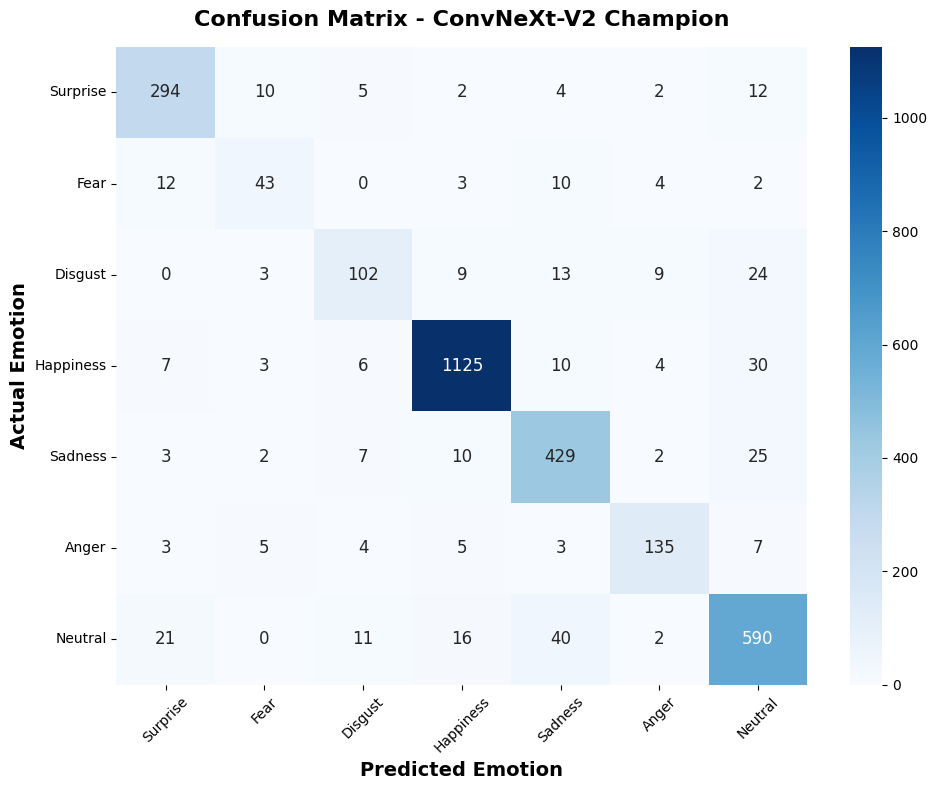

In [2]:
import os
import pandas as pd
import torch
import timm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm

# --- 1. Find Data & Setup Device ---
print("Scanning for CSV files...")
test_csv_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'test_labels.csv': 
            test_csv_path = os.path.join(dirname, filename)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 2. Self-Contained Dataset Class ---
class RAFDBDataset(Dataset):
    def __init__(self, csv_file, base_search_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform
        self.image_paths = {}
        for root, dirs, files in os.walk(base_search_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths[file] = os.path.join(root, file)

    def __len__(self): return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = self.data_frame.iloc[idx]['image']
        label = int(self.data_frame.iloc[idx]['label']) - 1 
        img_path = self.image_paths[img_name]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

# Test Transforms & Loader
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Building Test Loader...")
test_dataset = RAFDBDataset(csv_file=test_csv_path, base_search_dir='/kaggle/input', transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)


# --- 3. Initialize & Load ConvNeXt-V2 Champion ---
convnext_path = '/kaggle/input/datasets/hridyeshkumar/convnext-v2-champion/best_raf_emotion_model_v2.pth'
print("Initializing ConvNeXt-V2 Architecture...")

convnext_model = timm.create_model('convnextv2_tiny', pretrained=False, num_classes=7)
convnext_model = convnext_model.to(device)


# --- 4. Evaluation Function ---
def evaluate_champion_model(model, loader, device, model_name):
    model.eval()
    correct_7, correct_5, correct_3, total = 0, 0, 0, 0
    all_preds, all_labels = [], []
    
    # Reverse mapping lookups for scoring
    map_to_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}
    map_to_3 = {3:0, 0:1, 6:1, 1:2, 2:2, 4:2, 5:2}
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Testing {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # 7-Scale
            correct_7 += (preds == labels).sum().item()
            # 5-Scale
            preds_5 = torch.tensor([map_to_5[p.item()] for p in preds]).to(device)
            labels_5 = torch.tensor([map_to_5[l.item()] for l in labels]).to(device)
            correct_5 += (preds_5 == labels_5).sum().item()
            # 3-Scale
            preds_3 = torch.tensor([map_to_3[p.item()] for p in preds]).to(device)
            labels_3 = torch.tensor([map_to_3[l.item()] for l in labels]).to(device)
            correct_3 += (preds_3 == labels_3).sum().item()
            
    acc7 = (correct_7/total)*100
    acc5 = (correct_5/total)*100
    acc3 = (correct_3/total)*100
    
    print(f"✅ {model_name} Accuracy -> 7-Scale: {acc7:.2f}% | 5-Scale: {acc5:.2f}% | 3-Scale: {acc3:.2f}%\n")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=emotion_labels, yticklabels=emotion_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Actual Emotion', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Emotion', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --- 5. Execute ---
if os.path.exists(convnext_path):
    try:
        state_dict = torch.load(convnext_path, map_location=device)
        if 'model_state_dict' in state_dict:
            state_dict = state_dict['model_state_dict']
            
        convnext_model.load_state_dict(state_dict)
        print("✅ ConvNeXt-V2 Champion weights loaded successfully! Running inference...")
        evaluate_champion_model(convnext_model, test_loader, device, "ConvNeXt-V2 Champion")
        
    except Exception as e:
        print(f"❌ Error loading weights: {e}")
else:
    print(f"❌ File not found at: {convnext_path}")

In [3]:
import os
import shutil

print("Preparing DeiT model files...")
target_folder = None

# Scan for the unzipped DeiT files
for root, dirs, files in os.walk('/kaggle/input'):
    if '.format_version' in files and 'deit' in root.lower():
        target_folder = root
        break

rezipped_path = '/kaggle/working/fixed_deit_model.pth'

if target_folder:
    parent_dir = os.path.dirname(target_folder)
    folder_to_zip = os.path.basename(target_folder)
    
    # Repack into strict PyTorch format
    shutil.make_archive('/kaggle/working/temp_deit', 'zip', root_dir=parent_dir, base_dir=folder_to_zip)
    
    if os.path.exists(rezipped_path):
        os.remove(rezipped_path)
    os.rename('/kaggle/working/temp_deit.zip', rezipped_path)
    print(f"✅ DeiT model successfully repacked and ready for loading!")
else:
    print("❌ Could not find the unzipped DeiT model files.")

Preparing DeiT model files...
✅ DeiT model successfully repacked and ready for loading!


Initializing DeiT (Vision Transformer) Architecture...
✅ DeiT weights loaded! Running inference...


Testing DeiT (Vision Transformer):   0%|          | 0/96 [00:00<?, ?it/s]

✅ DeiT (Vision Transformer) Accuracy -> 7-Scale: 85.89% | 5-Scale: 87.26% | 3-Scale: 89.83%



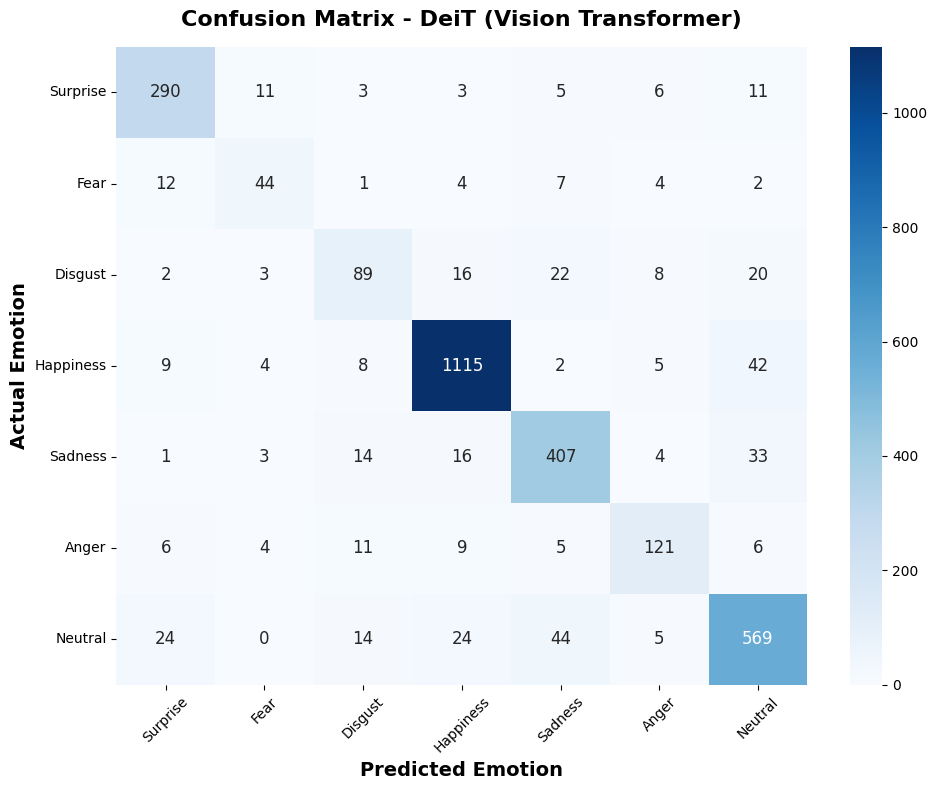

In [4]:
import torch
import timm
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm

# --- 1. Initialize DeiT Architecture ---
print("Initializing DeiT (Vision Transformer) Architecture...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

deit_model = timm.create_model('deit_tiny_patch16_224', pretrained=False, num_classes=7)
deit_model = deit_model.to(device)

# --- 2. Evaluation Function ---
def evaluate_deit_model(model, loader, device, model_name):
    model.eval()
    correct_7, correct_5, correct_3, total = 0, 0, 0, 0
    all_preds, all_labels = [], []
    
    map_to_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}
    map_to_3 = {3:0, 0:1, 6:1, 1:2, 2:2, 4:2, 5:2}
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Testing {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Scoring
            correct_7 += (preds == labels).sum().item()
            
            preds_5 = torch.tensor([map_to_5[p.item()] for p in preds]).to(device)
            labels_5 = torch.tensor([map_to_5[l.item()] for l in labels]).to(device)
            correct_5 += (preds_5 == labels_5).sum().item()
            
            preds_3 = torch.tensor([map_to_3[p.item()] for p in preds]).to(device)
            labels_3 = torch.tensor([map_to_3[l.item()] for l in labels]).to(device)
            correct_3 += (preds_3 == labels_3).sum().item()
            
    print(f"✅ {model_name} Accuracy -> 7-Scale: {(correct_7/total)*100:.2f}% | 5-Scale: {(correct_5/total)*100:.2f}% | 3-Scale: {(correct_3/total)*100:.2f}%\n")
    
    # Plotting
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Actual Emotion', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Emotion', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --- 3. Execute ---
rezipped_path = '/kaggle/working/fixed_deit_model.pth'

if 'test_loader' not in locals() and 'test_loader' not in globals():
    print("❌ Error: 'test_loader' not found! Make sure you run your initial data setup cell first.")
elif os.path.exists(rezipped_path):
    try:
        # Load weights passing the PyTorch 2.6 security check
        state_dict = torch.load(rezipped_path, map_location=device, weights_only=False)
        if 'model_state_dict' in state_dict:
            state_dict = state_dict['model_state_dict']
            
        deit_model.load_state_dict(state_dict)
        print("✅ DeiT weights loaded! Running inference...")
        evaluate_deit_model(deit_model, test_loader, device, "DeiT (Vision Transformer)")
        
    except Exception as e:
        print(f"❌ Error loading weights: {e}")
else:
    print(f"❌ Repacked model not found at: {rezipped_path}. Did you run Cell 1?")

Checking EfficientNet model path...
📂 Kaggle unzipped it into a directory. Finding the inner folder to repack...
Repacking the internal folder: best_raf_eff_model...
✅ Repacked successfully to /kaggle/working/fixed_effnet_model.pth!

Initializing EfficientNet-B0 Architecture...
✅ EfficientNet weights loaded! Running inference...


Testing EfficientNet-B0:   0%|          | 0/96 [00:00<?, ?it/s]

✅ EfficientNet-B0 Accuracy -> 7-Scale: 82.17% | 5-Scale: 83.25% | 3-Scale: 86.67%



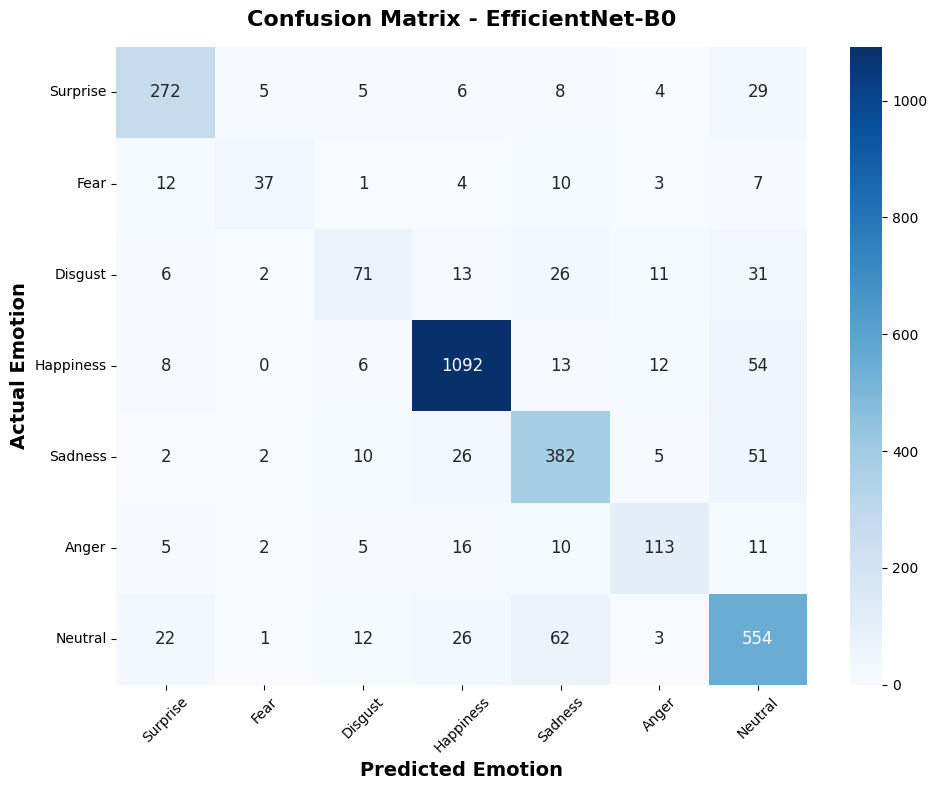

In [5]:
import torch
import timm
import os
import shutil
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm.notebook import tqdm

# --- 1. Smart Path Handling ---
eff_base_path = '/kaggle/input/datasets/hridyeshkumar/new-models-deit-efff/best_raf_eff_model.pth'
final_eff_path = None

print("Checking EfficientNet model path...")
if os.path.isfile(eff_base_path):
    print("✅ The path is a normal file! No repacking needed.")
    final_eff_path = eff_base_path
    
elif os.path.isdir(eff_base_path):
    print("📂 Kaggle unzipped it into a directory. Finding the inner folder to repack...")
    inner_folders = [f for f in os.listdir(eff_base_path) if os.path.isdir(os.path.join(eff_base_path, f))]
    
    if inner_folders:
        folder_to_zip = inner_folders[0]
        print(f"Repacking the internal folder: {folder_to_zip}...")
        
        rezipped_eff_path = '/kaggle/working/fixed_effnet_model.pth'
        shutil.make_archive('/kaggle/working/temp_effnet', 'zip', root_dir=eff_base_path, base_dir=folder_to_zip)
        
        if os.path.exists(rezipped_eff_path):
            os.remove(rezipped_eff_path)
        os.rename('/kaggle/working/temp_effnet.zip', rezipped_eff_path)
        
        final_eff_path = rezipped_eff_path
        print(f"✅ Repacked successfully to {final_eff_path}!")
    else:
        print("❌ Directory found, but no inner folders to repack. Contents:")
        print(os.listdir(eff_base_path))
else:
    print(f"❌ Path does not exist at all: {eff_base_path}")


# --- 2. Initialize EfficientNet Architecture ---
if final_eff_path:
    print("\nInitializing EfficientNet-B0 Architecture...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    eff_model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=7)
    eff_model = eff_model.to(device)

    # --- 3. Evaluation Function ---
    def evaluate_eff_model(model, loader, device, model_name):
        model.eval()
        correct_7, correct_5, correct_3, total = 0, 0, 0, 0
        all_preds, all_labels = [], []
        
        map_to_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}
        map_to_3 = {3:0, 0:1, 6:1, 1:2, 2:2, 4:2, 5:2}
        
        with torch.no_grad():
            for images, labels in tqdm(loader, desc=f"Testing {model_name}", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                
                total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                # Scoring
                correct_7 += (preds == labels).sum().item()
                
                preds_5 = torch.tensor([map_to_5[p.item()] for p in preds]).to(device)
                labels_5 = torch.tensor([map_to_5[l.item()] for l in labels]).to(device)
                correct_5 += (preds_5 == labels_5).sum().item()
                
                preds_3 = torch.tensor([map_to_3[p.item()] for p in preds]).to(device)
                labels_3 = torch.tensor([map_to_3[l.item()] for l in labels]).to(device)
                correct_3 += (preds_3 == labels_3).sum().item()
                
        print(f"✅ {model_name} Accuracy -> 7-Scale: {(correct_7/total)*100:.2f}% | 5-Scale: {(correct_5/total)*100:.2f}% | 3-Scale: {(correct_3/total)*100:.2f}%\n")
        
        # Plotting
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(10, 8))
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_labels, yticklabels=emotion_labels, annot_kws={"size": 12})
        plt.title(f'Confusion Matrix - {model_name}', fontsize=16, fontweight='bold', pad=15)
        plt.ylabel('Actual Emotion', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Emotion', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # --- 4. Execute ---
    if 'test_loader' not in locals() and 'test_loader' not in globals():
        print("❌ Error: 'test_loader' not found! Make sure you run your initial data setup cell first.")
    else:
        try:
            # Load weights passing the PyTorch 2.6 security check
            state_dict = torch.load(final_eff_path, map_location=device, weights_only=False)
            if 'model_state_dict' in state_dict:
                state_dict = state_dict['model_state_dict']
                
            eff_model.load_state_dict(state_dict)
            print("✅ EfficientNet weights loaded! Running inference...")
            evaluate_eff_model(eff_model, test_loader, device, "EfficientNet-B0")
            
        except Exception as e:
            print(f"❌ Error loading weights: {e}")

✅ All PyTorch models found in memory. Loading Smart Decider...
🧠 Running images through the Smart Decider Ensemble...


Ensemble Testing:   0%|          | 0/96 [00:00<?, ?it/s]


🏆 SMART DECIDER ENSEMBLE RESULTS 🏆
🔥 7-Scale Accuracy : 96.12%
🔥 5-Scale Accuracy : 96.38%
🔥 3-Scale Accuracy : 97.10%

📊 Detailed Classification Report (7-Scale):
              precision    recall  f1-score   support

    Surprise     0.9578    0.9666    0.9622       329
        Fear     0.9429    0.8919    0.9167        74
     Disgust     0.9338    0.8812    0.9068       160
   Happiness     0.9923    0.9797    0.9860      1185
     Sadness     0.9555    0.9435    0.9495       478
       Anger     0.9806    0.9383    0.9590       162
     Neutral     0.9192    0.9706    0.9442       680

    accuracy                         0.9612      3068
   macro avg     0.9546    0.9388    0.9463      3068
weighted avg     0.9618    0.9612    0.9613      3068



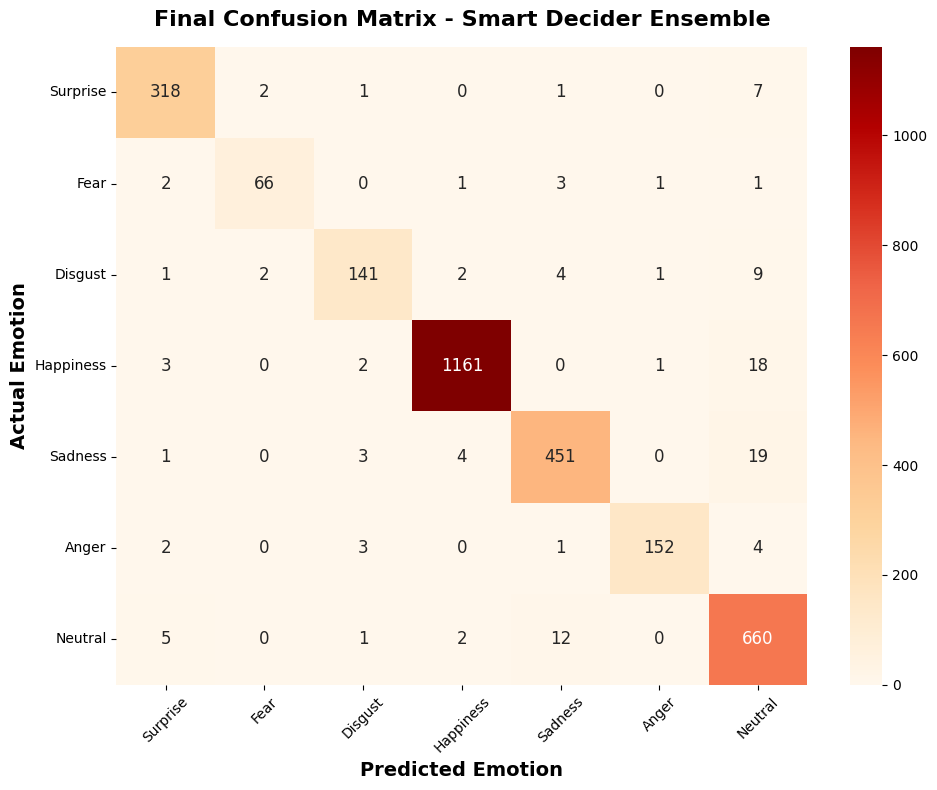

In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.notebook import tqdm

# --- 1. Path to your Smart Decider ---
ensemble_path = '/kaggle/input/datasets/hridyeshkumar/decider/smart_decider_ensemble.pkl'

if not os.path.exists(ensemble_path):
    ensemble_path = 'smart_decider_ensemble.pkl'
    if not os.path.exists(ensemble_path):
        ensemble_path = '/kaggle/input/smart_decider_ensemble.pkl'

# --- 2. Check Prerequisites ---
missing_models = []
if 'convnext_model' not in globals(): missing_models.append("ConvNeXt")
if 'deit_model' not in globals(): missing_models.append("DeiT")
if 'eff_model' not in globals(): missing_models.append("EfficientNet")
if 'test_loader' not in globals(): missing_models.append("test_loader")

if missing_models:
    print(f"❌ Error: Missing {', '.join(missing_models)} in memory. Make sure you ran the previous cells!")
elif not os.path.exists(ensemble_path):
    print(f"❌ Error: Could not find the Smart Decider file at: {ensemble_path}")
else:
    print("✅ All PyTorch models found in memory. Loading Smart Decider...")
    
    # Load the Random Forest
    rf_ensemble = joblib.load(ensemble_path)
    
    convnext_model.eval()
    deit_model.eval()
    eff_model.eval()
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    all_preds = []
    all_labels = []
    
    map_to_5 = {0:0, 1:0, 2:1, 5:1, 3:2, 4:3, 6:4}
    map_to_3 = {3:0, 0:1, 6:1, 1:2, 2:2, 4:2, 5:2}
    
    print("🧠 Running images through the Smart Decider Ensemble...")
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Ensemble Testing", leave=False):
            images = images.to(device)
            
            # 1. Get raw outputs and convert to probabilities
            probs_conv = F.softmax(convnext_model(images), dim=1).cpu().numpy()
            probs_deit = F.softmax(deit_model(images), dim=1).cpu().numpy()
            probs_eff = F.softmax(eff_model(images), dim=1).cpu().numpy()
            
            # 2. CRITICAL FIX: Stack in the exact order the RF was trained! (ConvNeXt -> DeiT -> EffNet)
            X_ensemble = np.hstack((probs_conv, probs_deit, probs_eff))
            
            # 3. Final prediction
            preds = rf_ensemble.predict(X_ensemble)
            
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    
    # --- 3. Calculate Final Accuracies ---
    all_preds_tensor = torch.tensor(all_preds)
    all_labels_tensor = torch.tensor(all_labels)
    total = len(all_labels)
    
    correct_7 = (all_preds_tensor == all_labels_tensor).sum().item()
    
    preds_5 = torch.tensor([map_to_5[p.item()] for p in all_preds_tensor])
    labels_5 = torch.tensor([map_to_5[l.item()] for l in all_labels_tensor])
    correct_5 = (preds_5 == labels_5).sum().item()
    
    preds_3 = torch.tensor([map_to_3[p.item()] for p in all_preds_tensor])
    labels_3 = torch.tensor([map_to_3[l.item()] for l in all_labels_tensor])
    correct_3 = (preds_3 == labels_3).sum().item()
    
    print("\n" + "="*50)
    print("🏆 SMART DECIDER ENSEMBLE RESULTS 🏆")
    print("="*50)
    print(f"🔥 7-Scale Accuracy : {(correct_7/total)*100:.2f}%")
    print(f"🔥 5-Scale Accuracy : {(correct_5/total)*100:.2f}%")
    print(f"🔥 3-Scale Accuracy : {(correct_3/total)*100:.2f}%")
    print("="*50 + "\n")
    
    emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
    print("📊 Detailed Classification Report (7-Scale):")
    print(classification_report(all_labels, all_preds, target_names=emotion_labels, digits=4))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', 
                xticklabels=emotion_labels, yticklabels=emotion_labels, annot_kws={"size": 12})
    
    plt.title('Final Confusion Matrix - Smart Decider Ensemble', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Actual Emotion', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Emotion', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

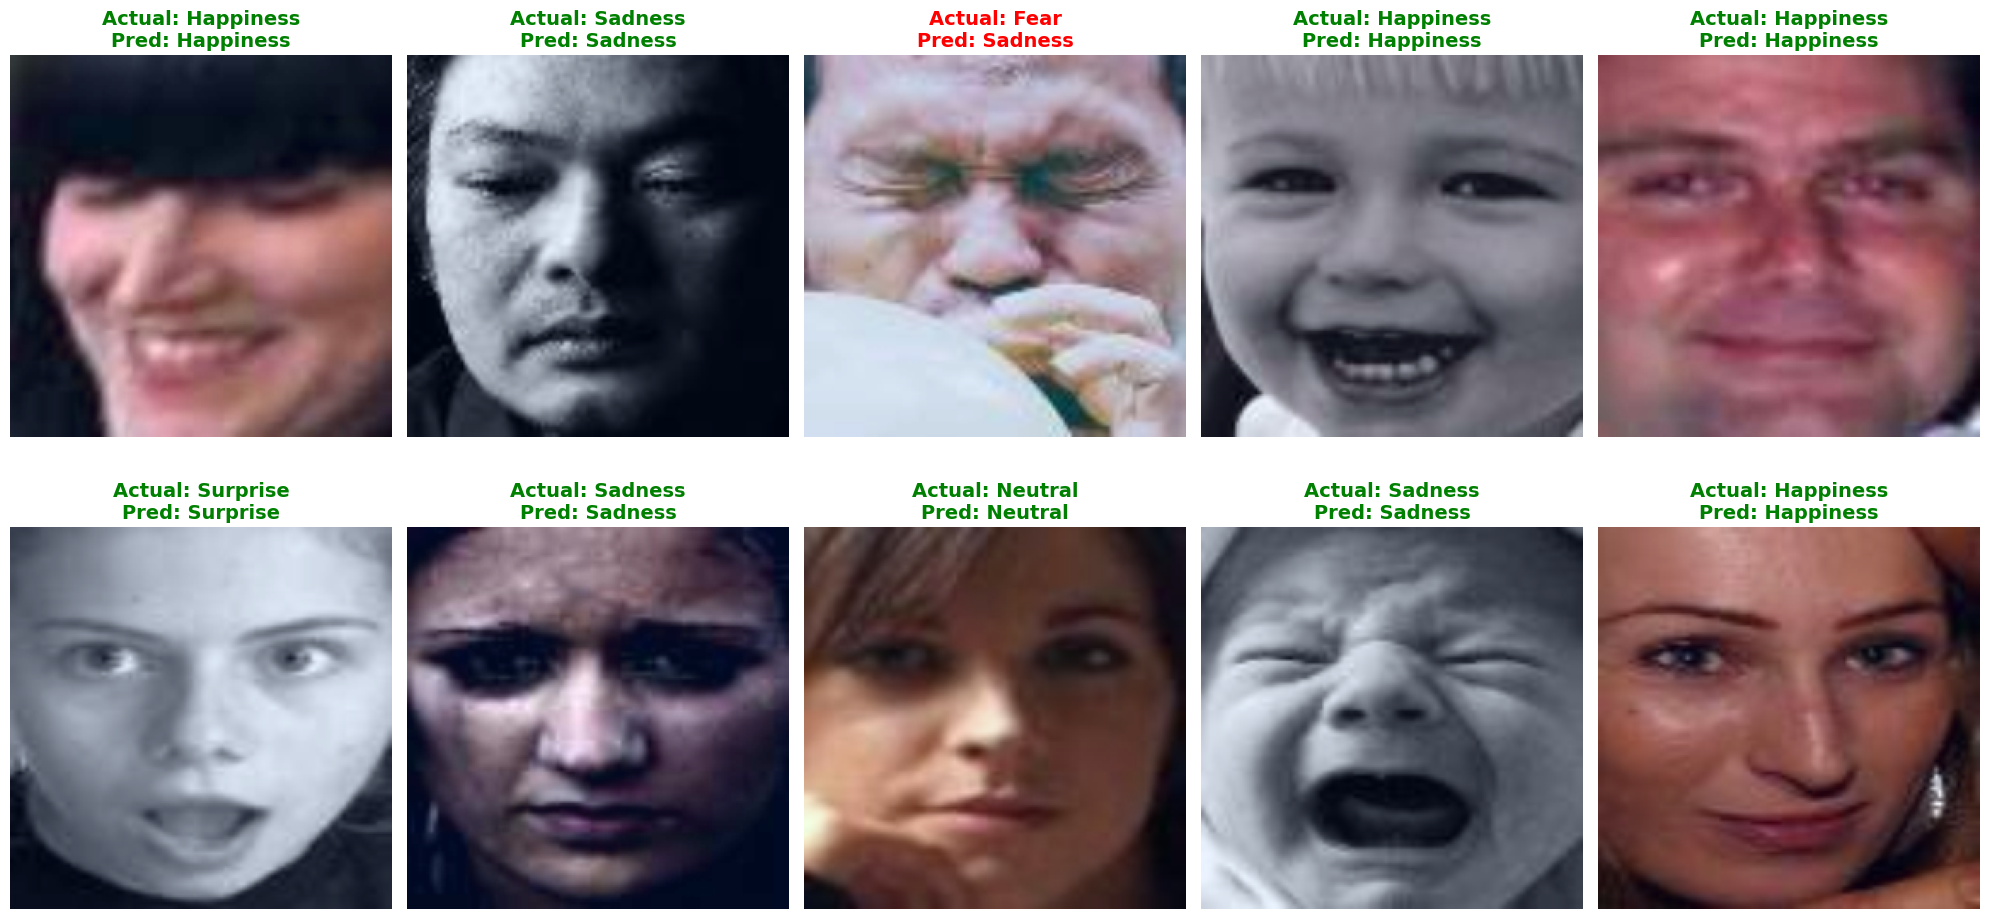

In [8]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import joblib

# 1. Setup Models & Mapping
# Make sure these match the names from your successful loading cells!
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTION_MAP = {0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'}

# Load the Smart Decider (Meta-Model)
# If you just trained 'rf_ensemble', we'll use that. Otherwise, we load the pkl.
if 'rf_ensemble' in globals():
    meta_model = rf_ensemble
else:
    try:
        meta_model = joblib.load('/kaggle/input/datasets/hridyeshkumar/decider/smart_decider_ensemble.pkl')
    except:
        meta_model = joblib.load('smart_decider_ensemble.pkl')

def get_ensemble_prediction(img_tensor):
    # USE THE CORRECT NAMES: convnext_model, deit_model, eff_model
    convnext_model.eval(); deit_model.eval(); eff_model.eval()
    
    with torch.no_grad():
        img_tensor = img_tensor.to(DEVICE)
        
        # Get probabilities from all 3 models
        p1 = F.softmax(convnext_model(img_tensor), dim=1).cpu().numpy()
        p2 = F.softmax(deit_model(img_tensor), dim=1).cpu().numpy()
        p3 = F.softmax(eff_model(img_tensor), dim=1).cpu().numpy()
        
        # Combine into the 21-feature vector (Order: ConvNeXt -> DeiT -> EffNet)
        meta_features = np.hstack([p1, p2, p3])
        final_pred = meta_model.predict(meta_features)
        return final_pred[0]

# 2. Pick 10 random images from the test set
if 'test_dataset' in globals():
    plt.figure(figsize=(20, 10))
    indices = np.random.choice(len(test_dataset), 10, replace=False)

    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]
        
        # Get the ensemble prediction
        pred_idx = get_ensemble_prediction(image.unsqueeze(0))
        
        # UI Logic
        actual_name = EMOTION_MAP[label]
        pred_name = EMOTION_MAP[pred_idx]
        color = 'green' if label == pred_idx else 'red'
        
        # Display the image
        plt.subplot(2, 5, i + 1)
        
        # Unnormalize for display: (image * std) + mean
        # Or simple min-max scaling for a quick look:
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
        
        plt.imshow(img_display)
        plt.title(f"Actual: {actual_name}\nPred: {pred_name}", color=color, fontsize=14, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("❌ Error: 'test_dataset' not found. Make sure you ran the Data Setup cell!")

In [9]:
import sys
import subprocess

# 1. Install without the "Restart" popup annoyance
subprocess.check_call([sys.executable, "-m", "pip", "install", "facenet-pytorch"])

# 2. Force Python to "see" the new library immediately
import site
from importlib import reload
reload(site)

print("✅ facenet-pytorch is now visible to the system!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<

✅ facenet-pytorch is now visible to the system!


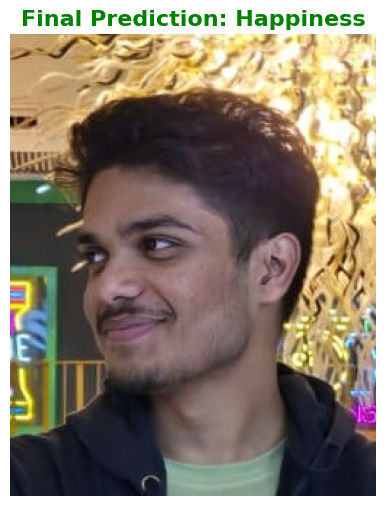

✅ Result: Happiness


In [10]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os

# Try to import MTCNN, but don't die if it fails
try:
    from facenet_pytorch import MTCNN
    HAS_MTCNN = True
except ImportError:
    HAS_MTCNN = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTION_MAP = {0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'}

# Initialize detector if possible
if HAS_MTCNN:
    mtcnn = MTCNN(keep_all=False, device=DEVICE, post_process=False)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_custom_image(image_path):
    if not os.path.exists(image_path):
        print(f"❌ Error: Image not found at {image_path}")
        return
        
    img_raw = Image.open(image_path).convert('RGB')
    
    # Logic: Use MTCNN if library is there, otherwise fallback to CenterCrop
    img_tensor = None
    if HAS_MTCNN:
        try:
            face = mtcnn(img_raw)
            if face is not None:
                face_img = transforms.ToPILImage()(face.byte())
                img_tensor = preprocess(face_img).unsqueeze(0).to(DEVICE)
        except Exception as e:
            print(f"⚠️ MTCNN error: {e}. Falling back to CenterCrop.")

    if img_tensor is None:
        # Standard fallback crop
        fallback_transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            preprocess
        ])
        img_tensor = fallback_transform(img_raw).unsqueeze(0).to(DEVICE)

    # Prediction using the clean rf_ensemble from the previous step
    convnext_model.eval(); deit_model.eval(); eff_model.eval()
    
    with torch.no_grad():
        p1 = F.softmax(convnext_model(img_tensor), dim=1).cpu().numpy()
        p2 = F.softmax(deit_model(img_tensor), dim=1).cpu().numpy()
        p3 = F.softmax(eff_model(img_tensor), dim=1).cpu().numpy()
        
        meta_features = np.hstack([p1, p2, p3])
        final_idx = rf_ensemble.predict(meta_features)[0]
        emotion = EMOTION_MAP[final_idx]

    plt.figure(figsize=(8, 6))
    plt.imshow(img_raw)
    plt.title(f"Final Prediction: {emotion}", fontsize=16, fontweight='bold', color='green')
    plt.axis('off')
    plt.show()
    print(f"✅ Result: {emotion}")

# RUN
target_file = '/kaggle/input/datasets/hridyeshkumar/vishal-emotion/vishal.jpeg'
predict_custom_image(target_file)

In [ ]:
# 1. Update/Reinstall yt-dlp
!pip install -U yt-dlp

# 2. Download forcing H.264 (avc1) format
import yt_dlp

video_url = 'https://www.youtube.com/shorts/JqAWYZp3gXk' 

ydl_opts = {
    # This specifically looks for H.264 (avc1) instead of AV1
    'format': 'bestvideo[vcodec^=avc1]+bestaudio[ext=m4a]/best[ext=mp4]/best',
    'outtmpl': '/kaggle/working/test_video.mp4',
    'overwrites': True,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([video_url])

print("\n✅ Video successfully downloaded in H.264 format!")

In [ ]:
import cv2
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from tqdm.notebook import tqdm
import numpy as np
import os

# --- 1. Settings ---
INPUT_VIDEO = '/kaggle/working/test_video.mp4' 
OUTPUT_PATH = '/kaggle/working/multi_emotion_result.mp4'
FRAME_SKIP = 3  # Increase this if it's too slow

# --- 2. Initialize Detector ---
from facenet_pytorch import MTCNN
mtcnn_multi = MTCNN(keep_all=True, device=DEVICE, post_process=False)

# --- 3. Setup & Verification ---
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    print(f"❌ Error: OpenCV still cannot read the video. Codec issue persists.")
else:
    # Check if the first frame is readable
    ret, test_frame = cap.read()
    if not ret:
        print("❌ Error: Video file exists but frames are unreadable.")
    else:
        print("✅ Video is readable! Starting Multi-Face Ensemble processing...")
        
        # Reset capture to frame 0
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        
        width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps    = int(cap.get(cv2.CAP_PROP_FPS))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

        current_faces_data = [] 

        for i in tqdm(range(total_frames)):
            ret, frame = cap.read()
            if not ret: break
            
            if i % FRAME_SKIP == 0:
                img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img_pil = Image.fromarray(img_rgb)
                
                boxes, _ = mtcnn_multi.detect(img_pil)
                current_faces_data = [] 

                if boxes is not None:
                    for box in boxes:
                        x1, y1, x2, y2 = [max(0, int(b)) for b in box]
                        face_crop = img_rgb[y1:y2, x1:x2]
                        
                        if face_crop.size > 0:
                            face_img = Image.fromarray(face_crop)
                            img_tensor = preprocess(face_img).unsqueeze(0).to(DEVICE)
                            
                            with torch.no_grad():
                                # Order: ConvNeXt -> DeiT -> EffNet
                                p1 = F.softmax(convnext_model(img_tensor), dim=1).cpu().numpy()
                                p2 = F.softmax(deit_model(img_tensor), dim=1).cpu().numpy()
                                p3 = F.softmax(eff_model(img_tensor), dim=1).cpu().numpy()
                                
                                meta_features = np.hstack([p1, p2, p3])
                                final_idx = rf_ensemble.predict(meta_features)[0]
                                label = EMOTION_MAP[final_idx]
                                current_faces_data.append((box, label))

            # Draw
            for box, label in current_faces_data:
                x1, y1, x2, y2 = [int(b) for b in box]
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.rectangle(frame, (x1, y1 - 35), (x1 + 150, y1), (0, 255, 0), -1)
                cv2.putText(frame, label, (x1 + 5, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

            out.write(frame)

        cap.release()
        out.release()
        print(f"✅ Processed video saved to: {OUTPUT_PATH}")